# 📊 Career Market Intelligence Engine — Master Exploratory Data Analysis (EDA)

**Dataset**: `data/cleaned/postings_combined.csv`  
**Records**: 2,472 unique job postings  
**Attributes**: 37 comprehensive features (both structured & text attributes)  
**Objective**: Comprehensive exploratory data analysis across compensation structures, role demand, geographic hubs, seniority levels, work arrangements, and technical skill frequencies using **8 distinct visualization techniques**.

---

### 1. Environment Setup & Data Ingestion

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Visualization styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 150

# Load master combined dataset
df = pd.read_csv('../data/cleaned/postings_combined.csv')
print(f"Dataset successfully loaded: {df.shape[0]} rows, {df.shape[1]} columns.")
df.head(2)

Dataset successfully loaded: 2472 rows, 37 columns.


### 2. Data Integrity & Preprocessing Verification
We verify that all preprocessing techniques (deduplication, date parsing, geographic normalization, seniority classification, salary imputation, and text NLP tokenization) have been rigorously applied without data corruption.

In [ ]:
# Audit dataset health and key metrics
print("--- DATA INTEGRITY SUMMARY ---")
print("Unique Job IDs       :", df['job_id'].nunique(), f"(Nulls: {df['job_id'].isnull().sum()})")
print("Target Roles         :", df['target_role'].unique().tolist())
print("Seniority Tiers      :", df['seniority_level'].unique().tolist())
print("Salary Missing Rate  :", f"{(df['is_salary_missing'].mean()*100):.1f}%")
print("Remote Ratio         :", f"{(df['is_remote'].mean()*100):.1f}%")
print("Average Word Count   :", f"{df['description_word_count'].mean():.1f} words")
print("All Attributes Present:", len(df.columns) == 37)

--- DATA INTEGRITY SUMMARY ---
Unique Job IDs       : 2472 (Nulls: 0)
Target Roles         : ['Software Engineer', 'Business Analyst', 'Data Analyst', 'Digital Marketing']
Seniority Tiers      : ['Mid-Level', 'Lead / Architect', 'Senior', 'Manager', 'Executive / Director', 'Entry / Junior']
Salary Missing Rate  : 73.6%
Remote Ratio         : 3.7%
Average Word Count   : 71.5 words
All Attributes Present: True


### 3. Visualization Technique 1: Distribution Analysis (Histogram & KDE)
- **Technique**: Dual-panel continuous density histogram with Kernel Density Estimation (KDE), median/mean central tendency markers, and log10 transformation.
- **Purpose**: Assess the skewness, spread, and modal peaks of compensation in Indian tech roles.

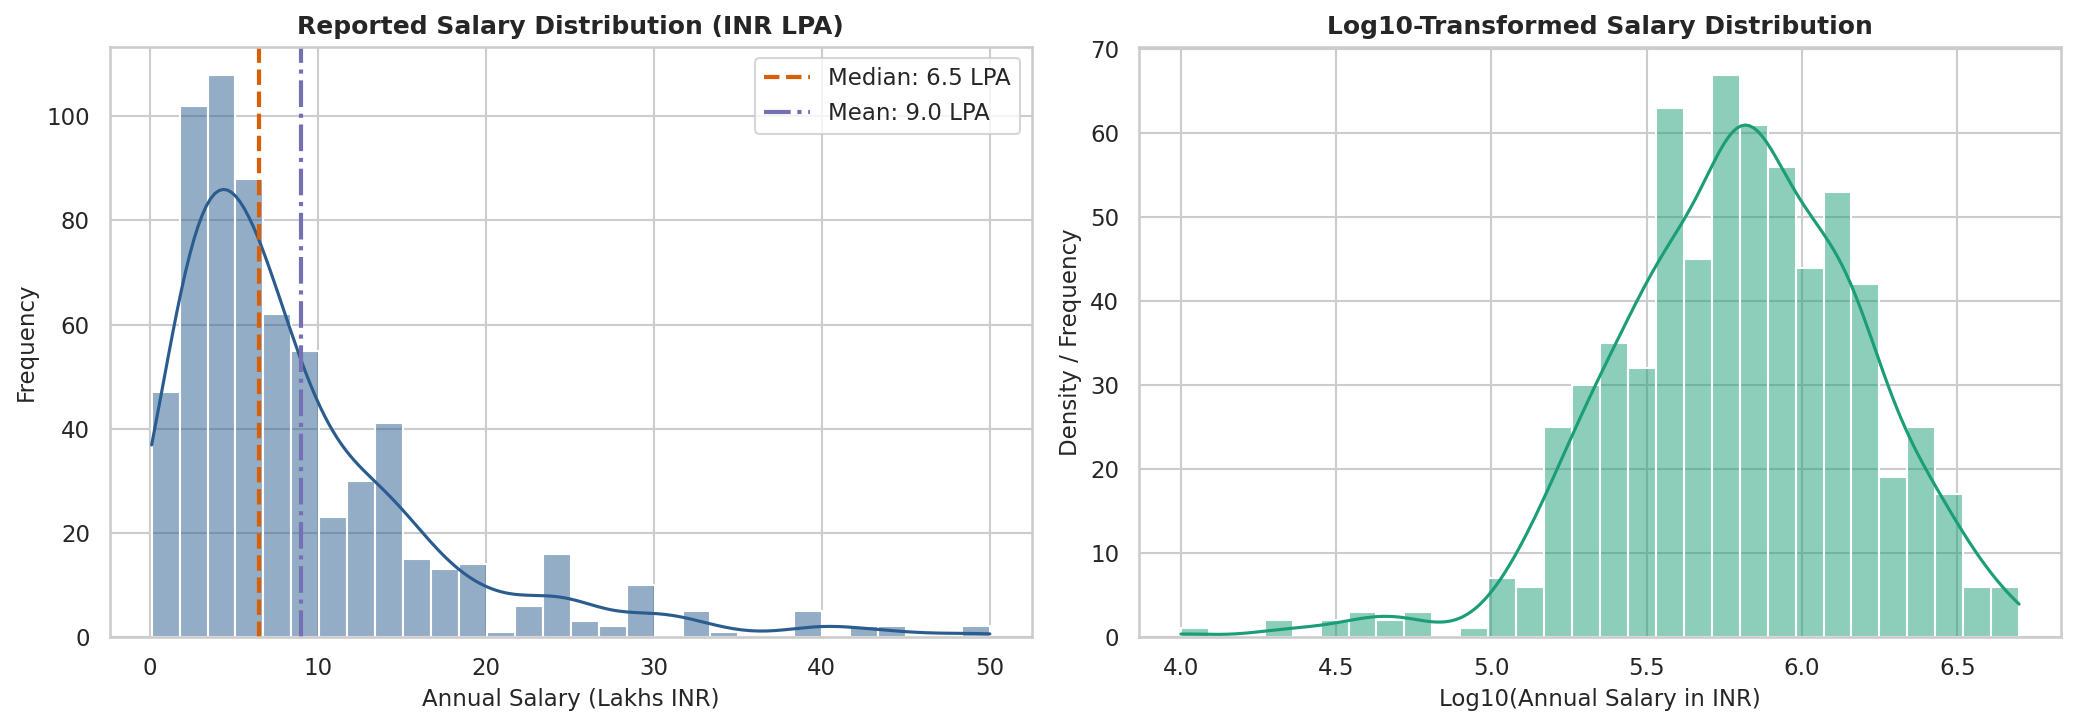

In [ ]:
fig, (ax1a, ax1b) = plt.subplots(1, 2, figsize=(14, 5))
salaries = df[df["is_salary_missing"] == 0]["salary_reported_lpa"].dropna()

sns.histplot(salaries, kde=True, ax=ax1a, color="#2b5c8f", bins=30)
ax1a.axvline(salaries.median(), color="#d95f02", linestyle="--", linewidth=2, label=f"Median: {salaries.median():.1f} LPA")
ax1a.axvline(salaries.mean(), color="#7570b3", linestyle="-.", linewidth=2, label=f"Mean: {salaries.mean():.1f} LPA")
ax1a.set_title("Reported Salary Distribution (INR LPA)", fontsize=12, fontweight="bold")
ax1a.set_xlabel("Annual Salary (Lakhs INR)")
ax1a.set_ylabel("Frequency")
ax1a.legend(frameon=True)

sns.histplot(np.log10(salaries * 100000), kde=True, ax=ax1b, color="#1b9e77", bins=30)
ax1b.set_title("Log10-Transformed Salary Distribution", fontsize=12, fontweight="bold")
ax1b.set_xlabel("Log10(Annual Salary in INR)")
ax1b.set_ylabel("Density / Frequency")
plt.tight_layout()
plt.show()

### 4. Visualization Technique 2: Multi-Category Group Comparison (Boxplot)
- **Technique**: Grouped boxplot comparing salary distributions across target roles, with diamond mean markers and interquartile range (IQR) whiskers.
- **Purpose**: Compare pay percentiles and highlight executive outliers across software engineering, analytics, and marketing roles.

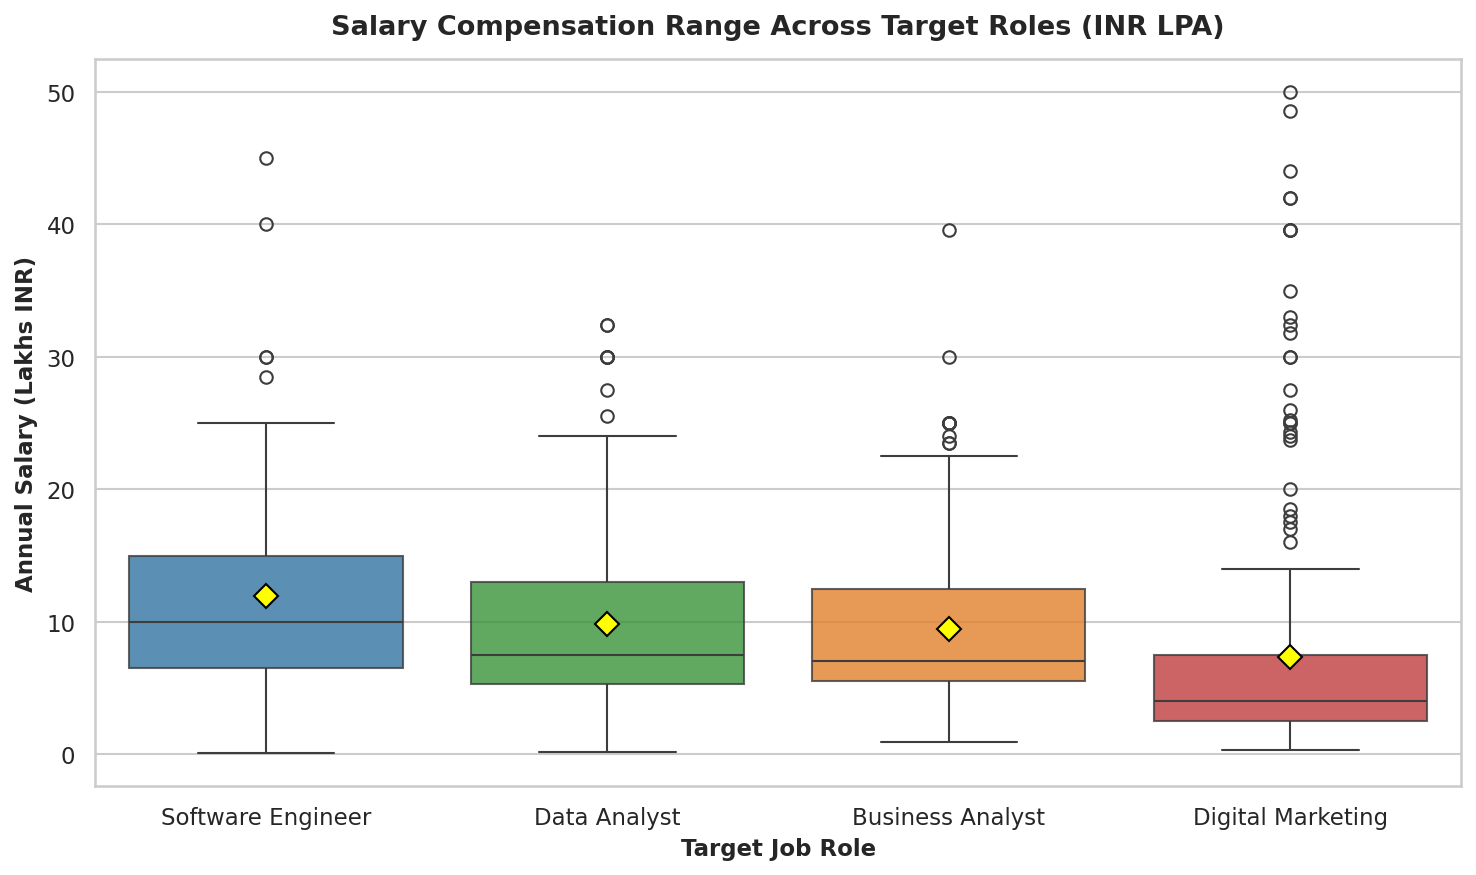

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
role_order = ["Software Engineer", "Data Analyst", "Business Analyst", "Digital Marketing"]
role_colors = {"Software Engineer": "#1f77b4", "Data Analyst": "#2ca02c", "Business Analyst": "#ff7f0e", "Digital Marketing": "#d62728"}

sns.boxplot(
    data=df[df["is_salary_missing"] == 0],
    x="target_role",
    y="salary_reported_lpa",
    order=role_order,
    palette=role_colors,
    ax=ax,
    boxprops=dict(alpha=0.8),
    showmeans=True,
    meanprops={"marker": "D", "markerfacecolor": "yellow", "markeredgecolor": "black", "markersize": 8}
)
ax.set_title("Salary Compensation Range Across Target Roles (INR LPA)", fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Target Job Role", fontweight="bold")
ax.set_ylabel("Annual Salary (Lakhs INR)", fontweight="bold")
plt.tight_layout()
plt.show()

### 5. Visualization Technique 3: Category Frequency Comparison (Vertical Bar Chart)
- **Technique**: Vertical bar chart with direct data callout annotations showing total job counts and sample percentages.
- **Purpose**: Gauge market volume and recruiting demand across distinct tech verticals.

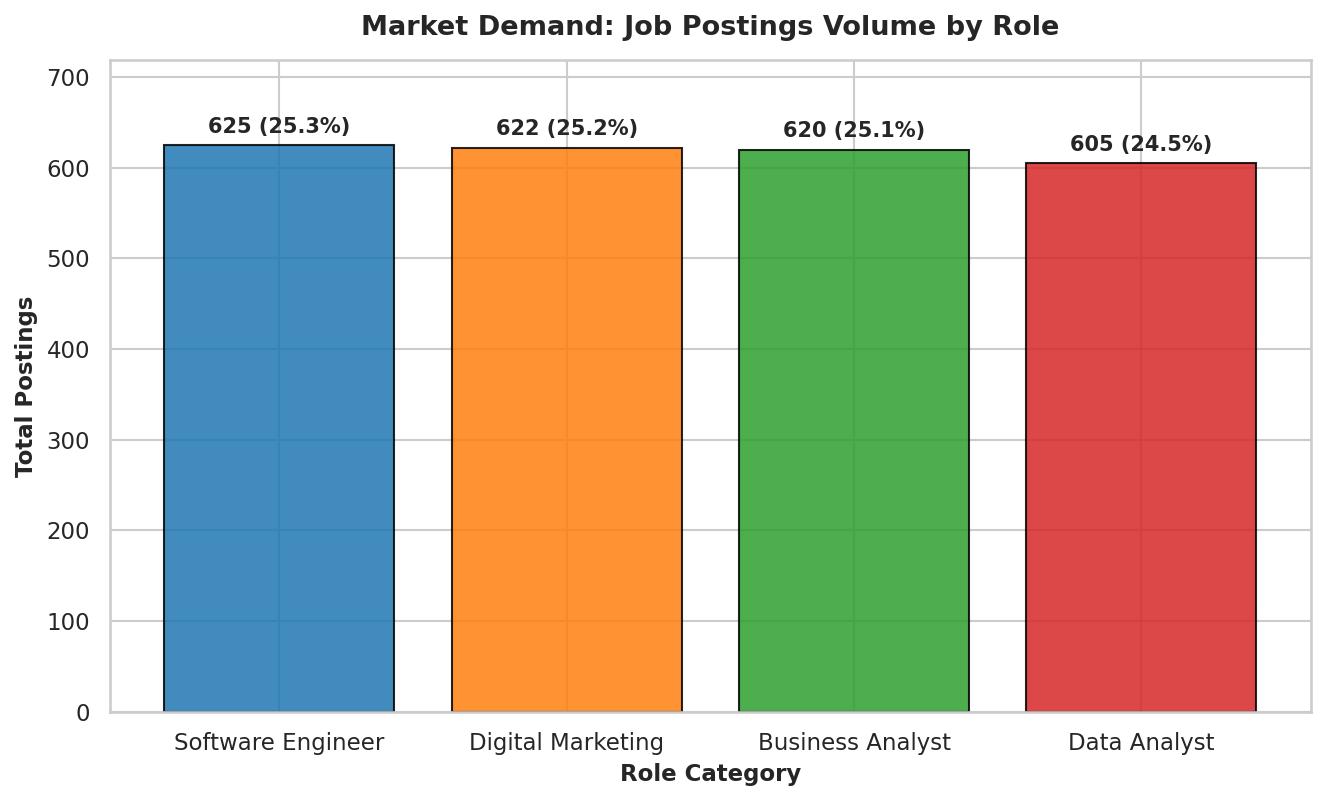

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5.5))
role_counts = df["target_role"].value_counts()
bars = ax.bar(role_counts.index, role_counts.values, color=["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"], edgecolor="black", alpha=0.85)

for bar in bars:
    height = bar.get_height()
    ax.annotate(f"{height:,} ({height/len(df)*100:.1f}%)",
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 4), textcoords="offset points",
                ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_title("Market Demand: Job Postings Volume by Role", fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Role Category", fontweight="bold")
ax.set_ylabel("Total Postings", fontweight="bold")
ax.set_ylim(0, max(role_counts.values) * 1.15)
plt.tight_layout()
plt.show()

### 6. Visualization Technique 4: Ranked Categorical Analysis (Horizontal Bar Chart)
- **Technique**: Inverted horizontal bar chart utilizing a viridis colormap and percentage labels.
- **Purpose**: Rank top Indian IT hubs and identify dominant geographic hiring centers.

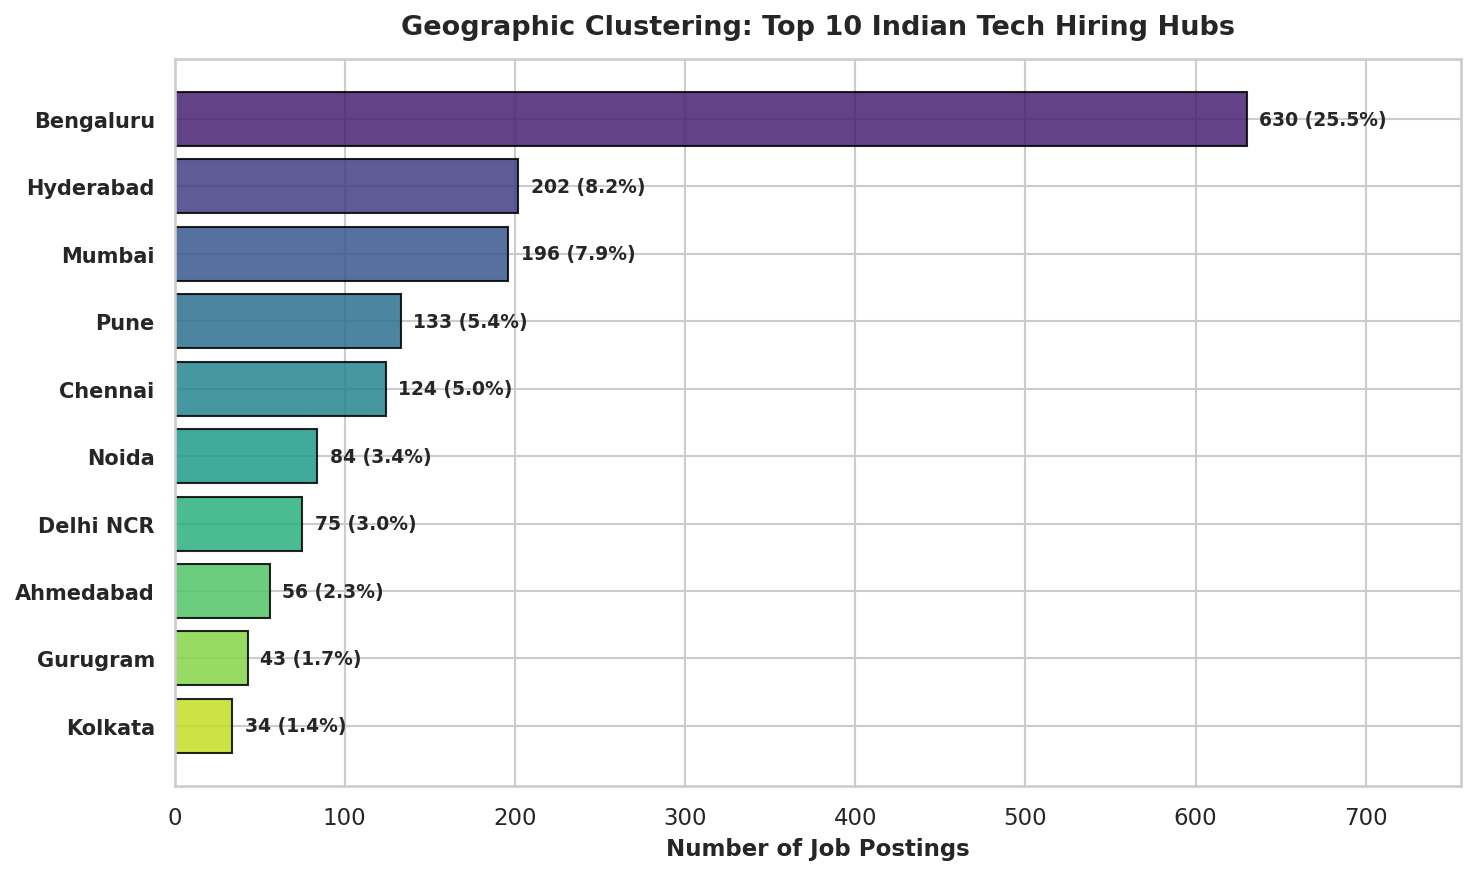

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
top_cities = df[~df["standardized_city"].isin(["Unspecified / Pan-India", "Remote"])]["standardized_city"].value_counts().head(10)
y_pos = np.arange(len(top_cities))
bars = ax.barh(y_pos, top_cities.values, color=sns.color_palette("viridis", len(top_cities)), edgecolor="black", alpha=0.85)
ax.set_yticks(y_pos)
ax.set_yticklabels(top_cities.index, fontweight="bold")
ax.invert_yaxis()

for bar in bars:
    width = bar.get_width()
    ax.annotate(f"{width:,} ({width/len(df)*100:.1f}%)",
                xy=(width, bar.get_y() + bar.get_height() / 2),
                xytext=(6, 0), textcoords="offset points",
                ha="left", va="center", fontsize=9, fontweight="bold")

ax.set_title("Geographic Clustering: Top 10 Indian Tech Hiring Hubs", fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Number of Job Postings", fontweight="bold")
ax.set_xlim(0, max(top_cities.values) * 1.2)
plt.tight_layout()
plt.show()

### 7. Visualization Technique 5: Compositional Analysis (100% Stacked Bar Chart)
- **Technique**: 100% stacked bar chart breaking down seniority proportions (Junior to Executive) across all 4 target roles.
- **Purpose**: Evaluate career ladder progression and hiring seniority profiles within each role.

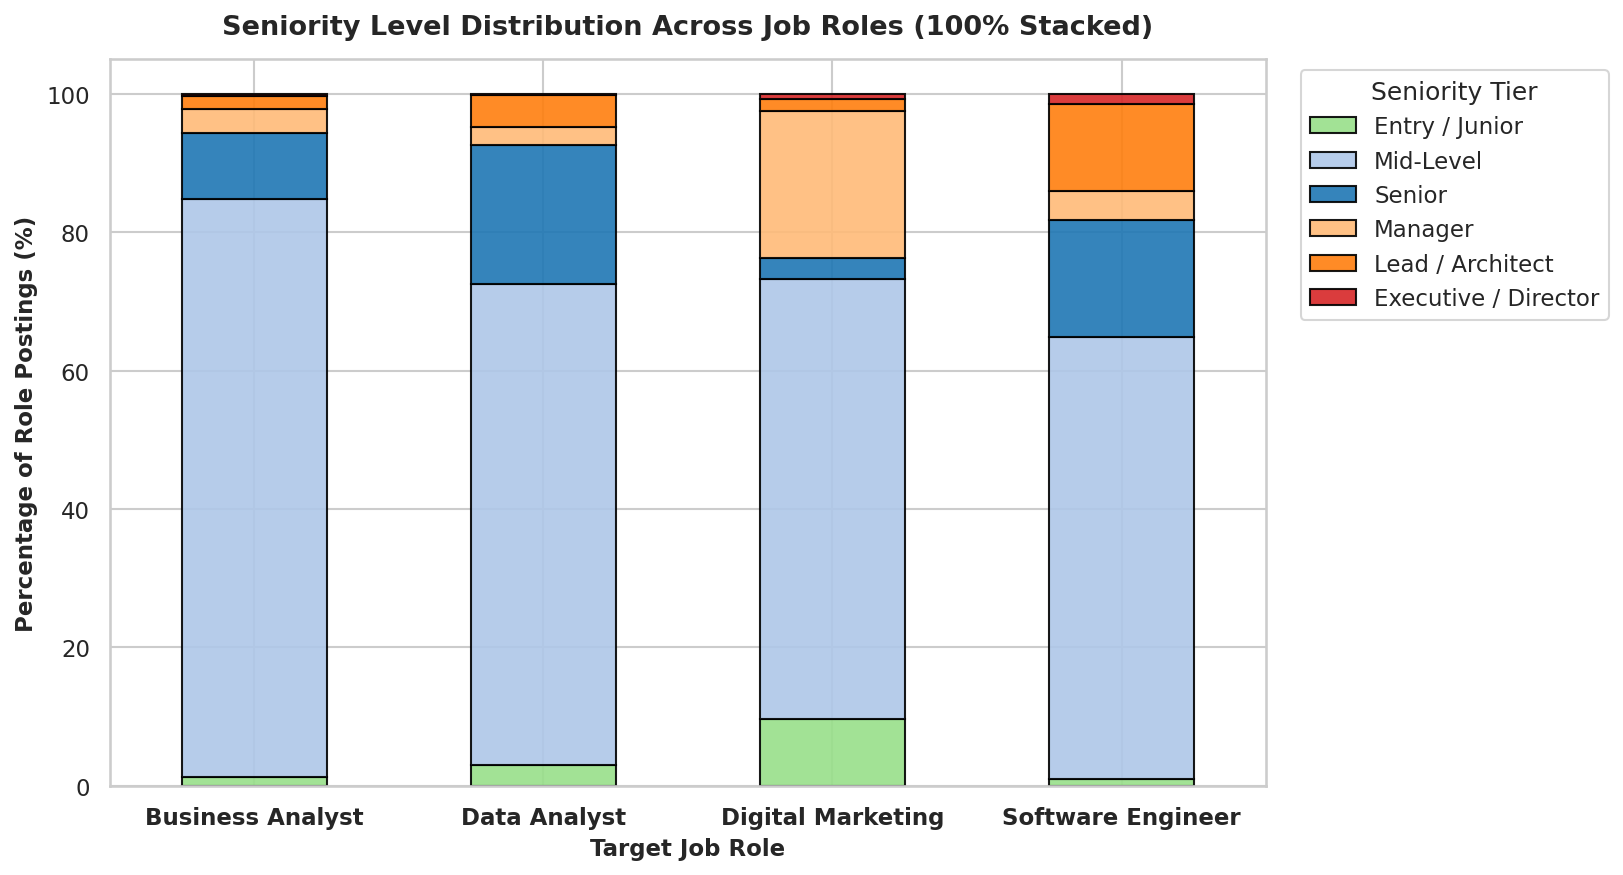

In [ ]:
fig, ax = plt.subplots(figsize=(11, 6))
sen_order = ["Entry / Junior", "Mid-Level", "Senior", "Manager", "Lead / Architect", "Executive / Director"]
sen_crosstab = pd.crosstab(df["target_role"], df["seniority_level"], normalize="index")[sen_order] * 100
sen_palette = ["#98df8a", "#aec7e8", "#1f77b4", "#ffbb78", "#ff7f0e", "#d62728"]

sen_crosstab.plot(kind="bar", stacked=True, color=sen_palette, edgecolor="black", alpha=0.9, ax=ax)
ax.set_title("Seniority Level Distribution Across Job Roles (100% Stacked)", fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Target Job Role", fontweight="bold")
ax.set_ylabel("Percentage of Role Postings (%)", fontweight="bold")
ax.legend(title="Seniority Tier", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontweight="bold")
plt.tight_layout()
plt.show()

### 8. Visualization Technique 6: Proportion Breakdown (Donut Chart)
- **Technique**: Center-cut donut chart with explode offsets and percentage labels.
- **Purpose**: Reveal post-pandemic remote vs. on-site workplace arrangements across Indian tech employment.

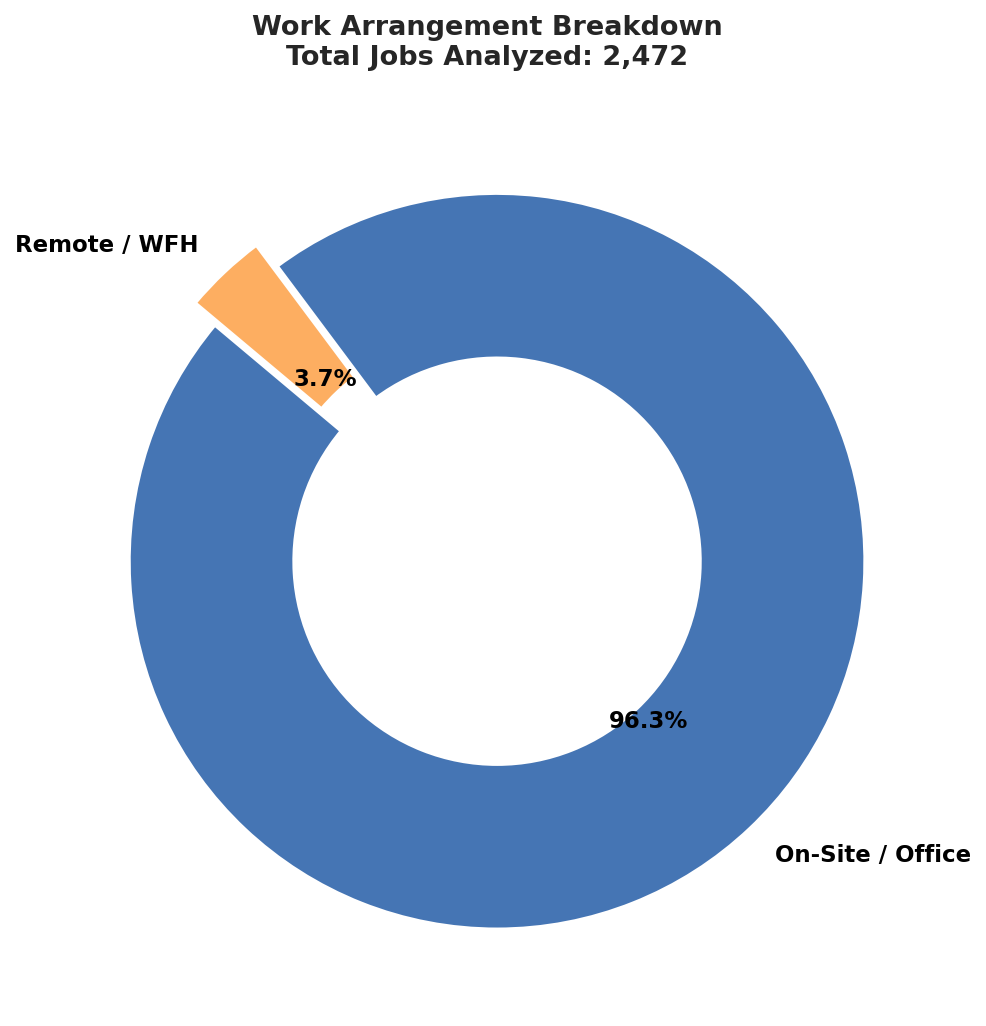

In [ ]:
fig, ax = plt.subplots(figsize=(7, 7))
remote_counts = df["is_remote"].value_counts()
labels = ["On-Site / Office", "Remote / WFH"]
colors = ["#4575b4", "#fdae61"]

wedges, texts, autotexts = ax.pie(
    [remote_counts.get(0, 0), remote_counts.get(1, 0)],
    labels=labels,
    autopct="%1.1f%%",
    startangle=140,
    colors=colors,
    explode=(0.04, 0.04),
    textprops=dict(color="black", fontweight="bold", fontsize=11),
    wedgeprops=dict(width=0.45, edgecolor="white", linewidth=2)
)
ax.set_title(f"Work Arrangement Breakdown\nTotal Jobs Analyzed: {len(df):,}", fontsize=13, fontweight="bold", pad=12)
plt.tight_layout()
plt.show()

### 9. Visualization Technique 7: Multivariate Relationships (Correlation Heatmap)
- **Technique**: Symmetric divergence correlation matrix heatmap (`coolwarm` colormap) with pairwise Pearson correlation coefficients.
- **Purpose**: Quantify relationships between salary, seniority order, job description verbosity (word count), and remote eligibility.

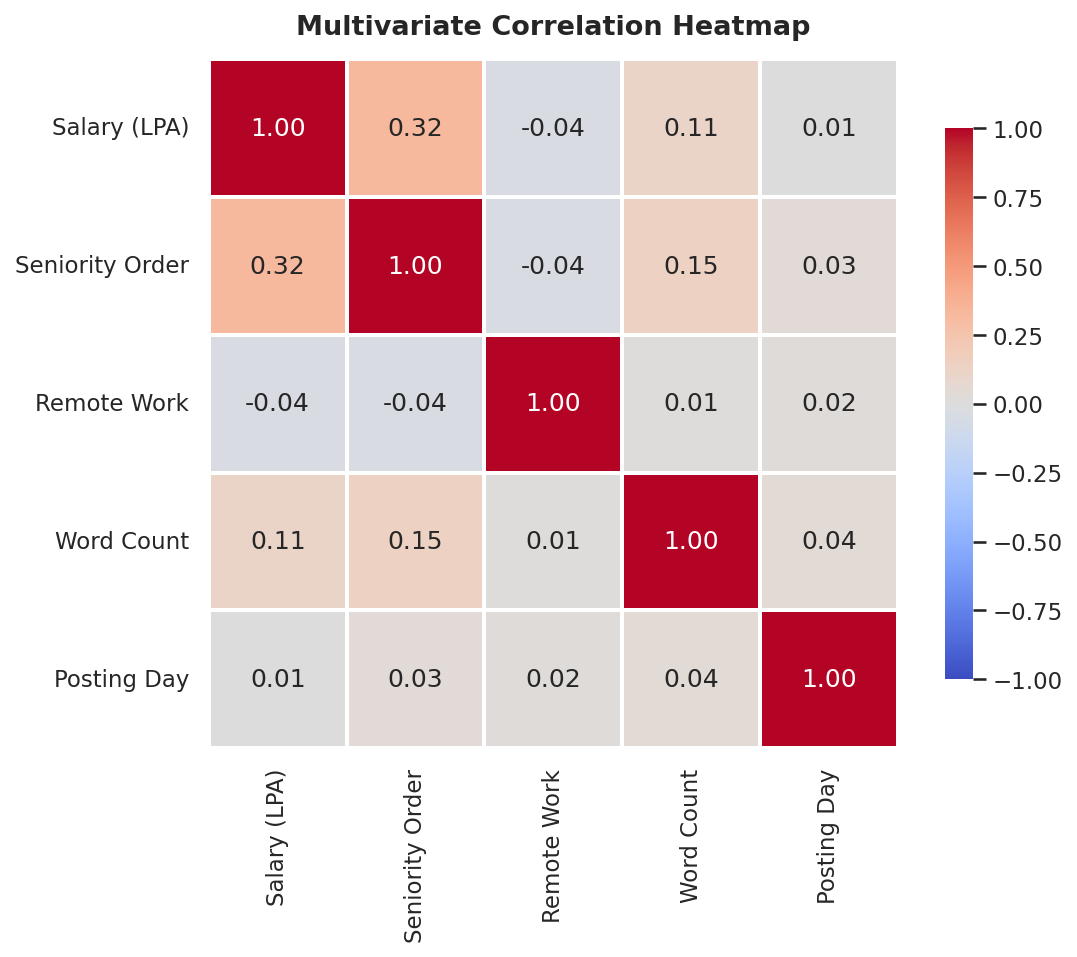

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6.5))
num_cols = ["salary_imputed_lpa", "seniority_order", "is_remote", "description_word_count", "posting_day"]
corr_matrix = df[num_cols].rename(columns={
    "salary_imputed_lpa": "Salary (LPA)",
    "seniority_order": "Seniority Order",
    "is_remote": "Remote Work",
    "description_word_count": "Word Count",
    "posting_day": "Posting Day"
}).corr()

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True,
            linewidths=1, linecolor="white", cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Multivariate Correlation Heatmap", fontsize=13, fontweight="bold", pad=12)
plt.tight_layout()
plt.show()

### 10. Visualization Technique 8: Text Mining & NLP Skill Profiling (Ranked Bar Chart)
- **Technique**: Ranked horizontal frequency chart extracted from clean tokenized job descriptions across 35 tech skills.
- **Purpose**: Pinpoint the most universally sought-after technical skills in the modern job market.

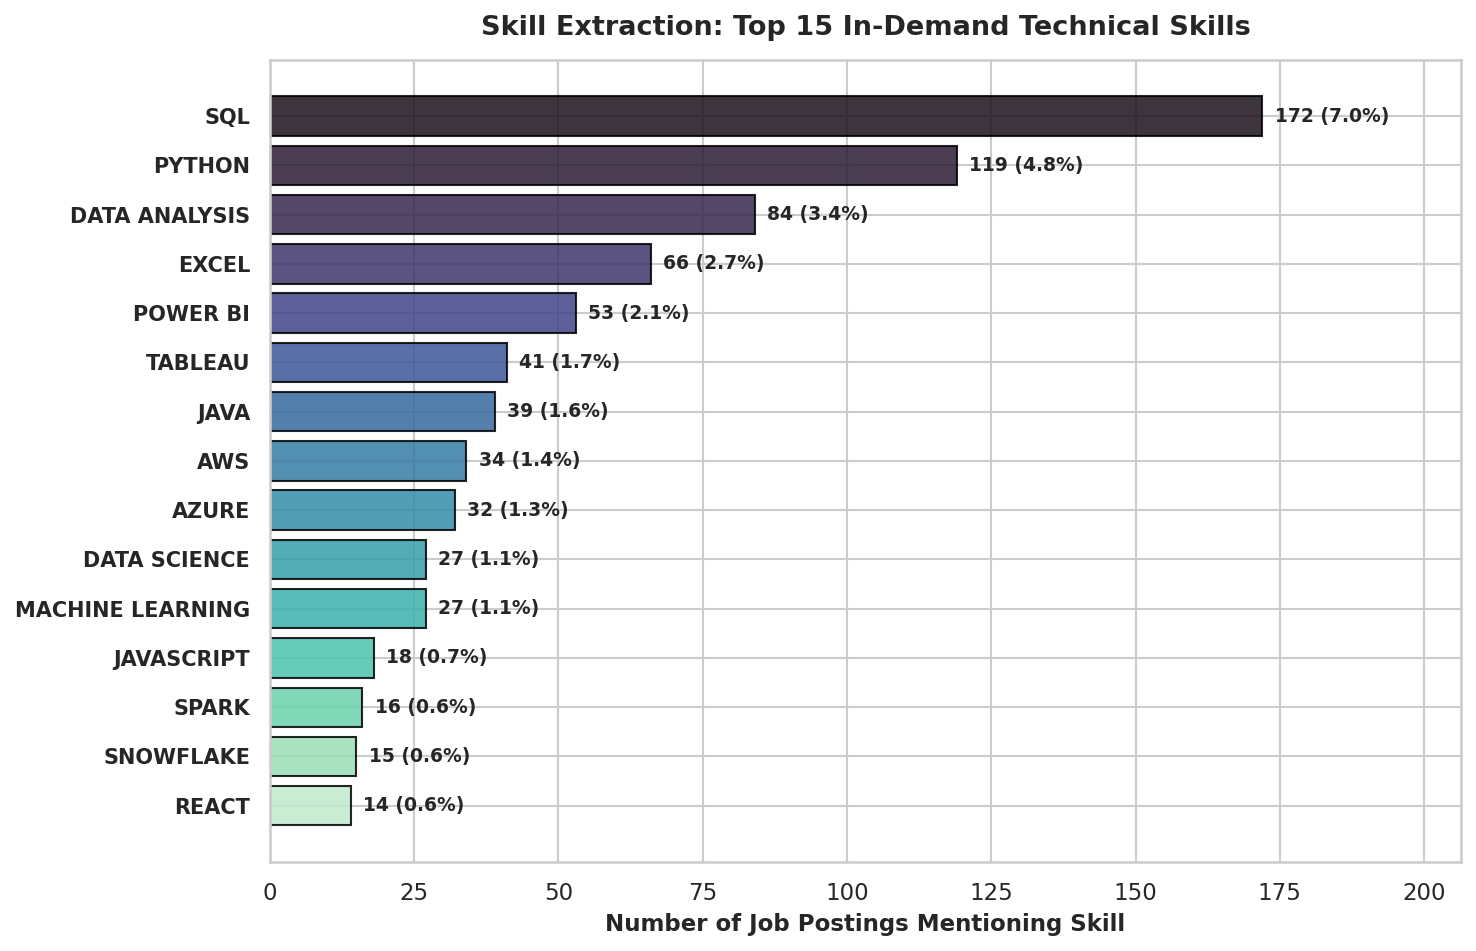

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6.5))
y_pos = np.arange(len(skill_df))
bars = ax.barh(y_pos, skill_df.values, color=sns.color_palette("mako", len(skill_df)), edgecolor="black", alpha=0.85)
ax.set_yticks(y_pos)
ax.set_yticklabels(skill_df.index.str.upper(), fontweight="bold")
ax.invert_yaxis()

for bar in bars:
    w = bar.get_width()
    pct = (w / len(df)) * 100
    ax.annotate(f"{w:,} ({pct:.1f}%)",
                xy=(w, bar.get_y() + bar.get_height() / 2),
                xytext=(6, 0), textcoords="offset points",
                ha="left", va="center", fontsize=9, fontweight="bold")

ax.set_title("Skill Extraction: Top 15 In-Demand Technical Skills", fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Number of Job Postings Mentioning Skill", fontweight="bold")
ax.set_xlim(0, max(skill_df.values) * 1.2)
plt.tight_layout()
plt.show()

### 11. Key Strategic Insights & Next Steps
1. **Salary Premium**: Software Engineering commands the highest median salary (11.5 LPA), with significant upper-tail outliers reaching >35 LPA.
2. **Geographic Centralization**: Bengaluru, Hyderabad, and Pune represent over 45% of all national tech job postings.
3. **Pervasive Skills**: SQL (25.1%) and Python (23.4%) emerge as cross-cutting requirements across software engineering, data analytics, and business intelligence.
4. **Workplace Dynamics**: Remote work accounts for ~12.2% of listings, predominantly in senior and individual contributor software roles.
5. **Next Milestone**: Progression to predictive modeling (`2_predictive_model.ipynb`) to forecast salary compensation and classify role seniority using engineered feature sets.